# Calculating the Annual Cycle for Daily Zonal Means of GPH from 1979-2023 (ERA5)

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d

In [2]:
filepath = '/glade/u/home/leonardgu/tam/Z_zonal_means/'

In [3]:
zmz2020file = filepath + 'zmzdaily2020.nc'

In [4]:
zmz2020 = xr.open_mfdataset(zmz2020file)

In [5]:
zmz2020


<xarray.Dataset> Size: 39MB
Dimensions:   (latitude: 721, level: 37, time: 366)
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * time      (time) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2020-12-31
Data variables:
    Z         (level, time, latitude) float32 39MB dask.array<chunksize=(37, 366, 721), meta=np.ndarray>

In [6]:
z2020 = zmz2020.Z

In [7]:
z2020

<xarray.DataArray 'Z' (level: 37, time: 366, latitude: 721)> Size: 39MB
dask.array<open_dataset-Z, shape=(37, 366, 721), dtype=float32, chunksize=(37, 366, 721), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * time      (time) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2020-12-31

Below is the function for interpolating leap years. It accepts a DataArray, the values of time from the dataset, and the year of the file as arguments.

In [8]:
def interpleapyear(z_data, year):
    level, time, latitude = z_data.shape
    print(str(year) + ' is a leap year!')
    orig = np.linspace(0, 1, 366)
    new = np.linspace(0, 1, 365)
    
    z_interp = np.zeros((level, 365, latitude))
    
    for lev in range(level):
        for lat in range(latitude):
            f = interp1d(orig, z_data[lev, :, lat], kind='linear',)
            z_interp[lev, :, lat] = f(new)
        
   # newtime = pd.date_range(start=f'{year}-01-01T00:00:00.000000000', periods=365, freq='D')
   
    z_interp_final = xr.DataArray(z_interp, dims = ['level', 'time', 'latitude'], coords = {'level': z_data.level, 'time': new, 'latitude': z_data.latitude}, name = 'Z')
    
    return z_interp_final

We want to test this function for now. Am I doing this right? Note that the year argument will be supplied via another function that actually iterates through years and performs the necessary calculations. Since 2020 is a known leap year, we will use this for testing.

In [9]:
test = interpleapyear(zmz2020.Z, 2020) # put 2020 here for now because just testing

2020 is a leap year!


In [10]:
test

<xarray.DataArray 'Z' (level: 37, time: 365, latitude: 721)> Size: 78MB
array([[[ 4.37911016e+04,  4.37911641e+04,  4.37919180e+04, ...,
          5.03435781e+04,  5.03442148e+04,  5.03443438e+04],
        [ 4.38839548e+04,  4.38842046e+04,  4.38849192e+04, ...,
          5.03439473e+04,  5.03445374e+04,  5.03446314e+04],
        [ 4.44154418e+04,  4.44155977e+04,  4.44162383e+04, ...,
          5.03432015e+04,  5.03438851e+04,  5.03440489e+04],
        ...,
        [ 4.41161567e+04,  4.41162775e+04,  4.41166629e+04, ...,
          5.03014483e+04,  5.03016593e+04,  5.03016906e+04],
        [ 4.42674522e+04,  4.42677096e+04,  4.42684898e+04, ...,
          5.03179000e+04,  5.03181382e+04,  5.03181695e+04],
        [ 4.48509062e+04,  4.48511758e+04,  4.48519883e+04, ...,
          5.03365547e+04,  5.03368203e+04,  5.03368789e+04]],

       [[ 3.85086133e+04,  3.85089570e+04,  3.85103164e+04, ...,
          4.44328008e+04,  4.44330195e+04,  4.44330664e+04],
        [ 3.85332868e+04,  3.85334863e+04,  3.85344867e+04, ...,
          4.44251650e+04,  4.44253406e+04,  4.44253680e+04],
        [ 3.88093301e+04,  3.88096511e+04,  3.88107775e+04, ...,
          4.44226635e+04,  4.44227696e+04,  4.44227969e+04],
...
        [ 3.38338099e+02,  3.38302651e+02,  3.38467023e+02, ...,
          4.51617302e+01,  4.69452347e+01,  4.72659133e+01],
        [ 3.37804923e+02,  3.37745023e+02,  3.38071057e+02, ...,
          6.96805592e+01,  7.11960934e+01,  7.15812682e+01],
        [ 3.39528992e+02,  3.39446136e+02,  3.39269653e+02, ...,
          1.06749069e+02,  1.08868942e+02,  1.09451408e+02]],

       [[ 3.41661987e+01,  3.41767921e+01,  3.40290565e+01, ...,
         -5.29675903e+01, -5.21925240e+01, -5.19482841e+01],
        [ 6.91183606e+01,  6.91039514e+01,  6.89739234e+01, ...,
         -5.15814875e+01, -5.07580470e+01, -5.05909173e+01],
        [ 5.04703380e+01,  5.04984884e+01,  5.06092402e+01, ...,
         -4.82095810e+01, -4.74865848e+01, -4.72699635e+01],
        ...,
        [ 1.46911516e+02,  1.46873671e+02,  1.47090781e+02, ...,
         -1.53418389e+02, -1.51550291e+02, -1.51220397e+02],
        [ 1.42484277e+02,  1.42421465e+02,  1.42803508e+02, ...,
         -1.28508693e+02, -1.26937514e+02, -1.26535925e+02],
        [ 1.42230942e+02,  1.42141663e+02,  1.42021378e+02, ...,
         -9.13536758e+01, -8.91555710e+01, -8.85555954e+01]]])
Coordinates:
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * time      (time) float64 3kB 0.0 0.002747 0.005495 ... 0.9945 0.9973 1.0
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0

In [11]:
new = np.linspace(0,1,366)

In [12]:
z2020norm = z2020.assign_coords({'time': new})

Hmm..365 for the time dimension. Let's compare it with the uninterpolated dataset:

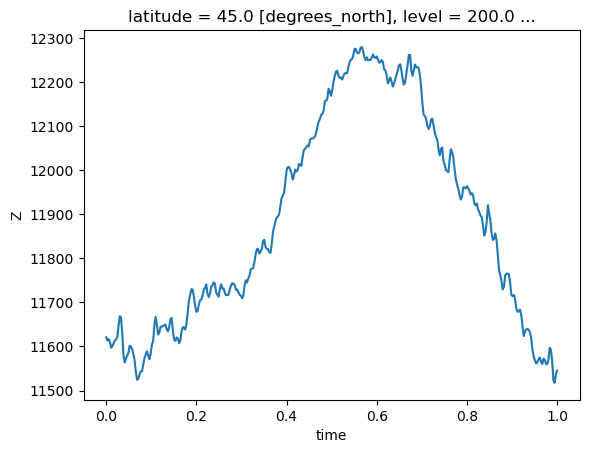

In [13]:
z2020norm.sel(latitude = 45, level = 200).plot()

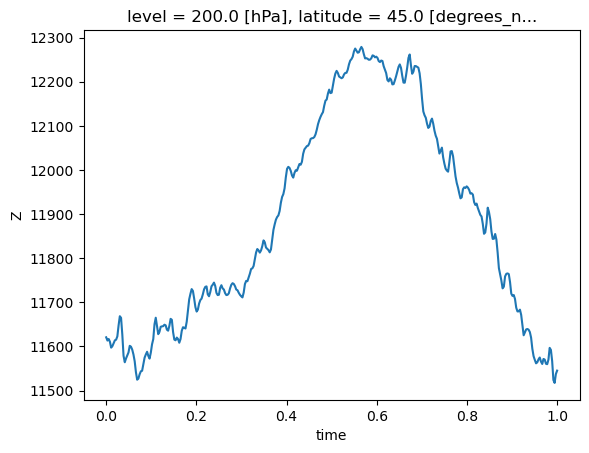

In [14]:
test.sel(latitude = 45, level = 200).plot()

In [67]:
test.time

<xarray.DataArray 'time' (time: 365)> Size: 3kB
array([0.      , 0.002747, 0.005495, ..., 0.994505, 0.997253, 1.      ])
Coordinates:
  * time     (time) float64 3kB 0.0 0.002747 0.005495 ... 0.9945 0.9973 1.0

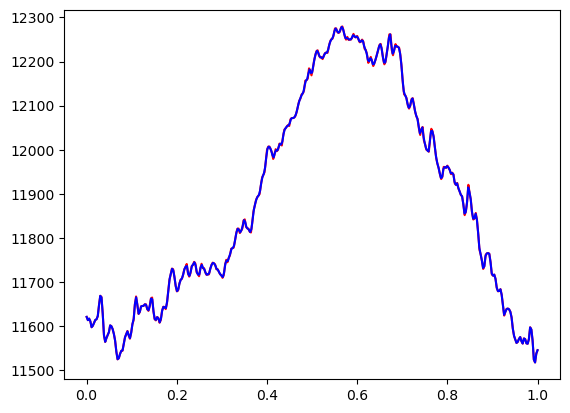

In [15]:
plt.plot(z2020norm.sel(latitude = 45, level = 200).time, z2020norm.sel(latitude = 45, level = 200), color = 'red') # non interpolated
plt.plot(test.sel(latitude = 45, level = 200).time, test.sel(latitude = 45, level = 200), color = 'blue') # interpolated


Looks good to me! I don't see any striking differences between the time series curve. In fact, there's a bit of smoothness in the interpolated curve...especially at the peak (see around July).

Now we calculate the annual cycle for daily zonal means of GPH, using the previous interpolation function for the leap years.

In [76]:
def annual_cycle(filepath):
    yeardata = []
    level_coords = None
    lat_coords = None
    #shapes = [] # for debugging purposes, resolved already
    for year in range(1979, 2024):
        file_path = f"{filepath}/zmzdaily{year}.nc"

        ds = xr.open_dataset(file_path)
        z_data = ds.Z.load()
        origtime = ds.time.values
        print(f"Year {year}: original shape = {z_data.shape}")

        # Storing coords for a non-leap year
        if level_coords is None and lat_coords is None:
            level_coords = z_data.level
            lat_coords = z_data.latitude
        if year == 1979:
            z_data = z_data.transpose('level','time','latitude') # because for some reason 1979 saved with diff order of dims
        if z_data.shape[1] == 366:
            z_interped = interpleapyear(z_data, year)

        else:
            z_interped = z_data
            
        #print(f"  -> Final shape = {z_interped.shape}")
        #shapes.append(z_interped.shape)
        yeardata.append(z_interped)
    #unique_shapes = list(set(shapes))
   # print(f"\nUnique shapes found: {unique_shapes}")
    """
    if len(unique_shapes) > 1:
        print("ERROR: Not all arrays have the same shape!")
        for i, shape in enumerate(shapes):
            print(f"Year {1979 + i}: {shape}")
        return None, None  
     
    reference_dates = pd.date_range('2001-01-01', periods=365, freq='D')
    clim_time = [f"{dt.month:02d}-{dt.day:02d}" for dt in reference_dates]
    """
    clim_time = np.arange(1,366) # cheesing
    totalyears = np.stack(yeardata, axis=0)
    annualcycle_val = np.mean(totalyears, axis=0)
    annualcycle = xr.DataArray(annualcycle_val, dims=['level', 'time', 'latitude'], coords = {'level': level_coords, 'time': clim_time, 'latitude': lat_coords}, name = 'Z')
    return annualcycle

In [77]:
annualcycda = annual_cycle(filepath)

Year 1979: original shape = (365, 37, 721)
Year 1980: original shape = (37, 366, 721)
1980 is a leap year!
Year 1981: original shape = (37, 365, 721)
Year 1982: original shape = (37, 365, 721)
Year 1983: original shape = (37, 365, 721)
Year 1984: original shape = (37, 366, 721)
1984 is a leap year!
Year 1985: original shape = (37, 365, 721)
Year 1986: original shape = (37, 365, 721)
Year 1987: original shape = (37, 365, 721)
Year 1988: original shape = (37, 366, 721)
1988 is a leap year!
Year 1989: original shape = (37, 365, 721)
Year 1990: original shape = (37, 365, 721)
Year 1991: original shape = (37, 365, 721)
Year 1992: original shape = (37, 366, 721)
1992 is a leap year!
Year 1993: original shape = (37, 365, 721)
Year 1994: original shape = (37, 365, 721)
Year 1995: original shape = (37, 365, 721)
Year 1996: original shape = (37, 366, 721)
1996 is a leap year!
Year 1997: original shape = (37, 365, 721)
Year 1998: original shape = (37, 365, 721)
Year 1999: original shape = (37, 36

In [78]:
annualcycda

<xarray.DataArray 'Z' (level: 37, time: 365, latitude: 721)> Size: 78MB
array([[[ 4.41970674e+04,  4.41973577e+04,  4.41977231e+04, ...,
          5.05083787e+04,  5.05086793e+04,  5.05087420e+04],
        [ 4.42760484e+04,  4.42763741e+04,  4.42767606e+04, ...,
          5.05064969e+04,  5.05068122e+04,  5.05068713e+04],
        [ 4.43852433e+04,  4.43854887e+04,  4.43856947e+04, ...,
          5.05034886e+04,  5.05038106e+04,  5.05038642e+04],
        ...,
        [ 4.39138060e+04,  4.39140473e+04,  4.39145615e+04, ...,
          5.04939178e+04,  5.04942154e+04,  5.04942568e+04],
        [ 4.40759311e+04,  4.40763964e+04,  4.40768140e+04, ...,
          5.04970127e+04,  5.04973049e+04,  5.04973654e+04],
        [ 4.41912933e+04,  4.41918765e+04,  4.41922003e+04, ...,
          5.04987568e+04,  5.04990662e+04,  5.04991467e+04]],

       [[ 3.92617000e+04,  3.92619636e+04,  3.92623200e+04, ...,
          4.46046924e+04,  4.46049016e+04,  4.46049433e+04],
        [ 3.93270252e+04,  3.93273041e+04,  3.93276151e+04, ...,
          4.46036573e+04,  4.46038757e+04,  4.46039210e+04],
        [ 3.93995747e+04,  3.93998020e+04,  3.94001063e+04, ...,
          4.46018347e+04,  4.46020538e+04,  4.46020936e+04],
...
        [ 3.06710228e+02,  3.06845160e+02,  3.06784031e+02, ...,
          1.93409811e+02,  1.95030840e+02,  1.95289822e+02],
        [ 2.96570894e+02,  2.96719049e+02,  2.96690580e+02, ...,
          2.00746857e+02,  2.02402692e+02,  2.02722529e+02],
        [ 3.03754587e+02,  3.03879581e+02,  3.03839641e+02, ...,
          2.01572346e+02,  2.03383812e+02,  2.03882185e+02]],

       [[ 1.20187799e+02,  1.20205374e+02,  1.20128956e+02, ...,
          4.36043497e+00,  6.21343278e+00,  6.74978049e+00],
        [ 1.10775746e+02,  1.10783242e+02,  1.10746157e+02, ...,
          9.29211582e+00,  1.10517727e+01,  1.14833639e+01],
        [ 1.13850901e+02,  1.13883080e+02,  1.13801137e+02, ...,
          1.19307358e+00,  2.82330860e+00,  3.19197599e+00],
        ...,
        [ 1.21353541e+02,  1.21482651e+02,  1.21405938e+02, ...,
         -5.58168753e+00, -3.87821851e+00, -3.60678216e+00],
        [ 1.10577309e+02,  1.10730573e+02,  1.10699708e+02, ...,
          1.78821049e+00,  3.53049247e+00,  3.86602714e+00],
        [ 1.18004413e+02,  1.18122582e+02,  1.18074158e+02, ...,
          2.48514913e+00,  4.39688022e+00,  4.92352515e+00]]])
Coordinates:
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * time      (time) int64 3kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0

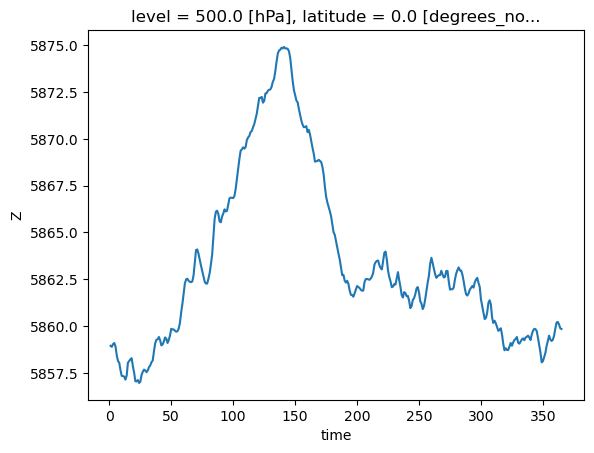

In [79]:
annualcycda.sel(latitude = 0, level = 500).plot()

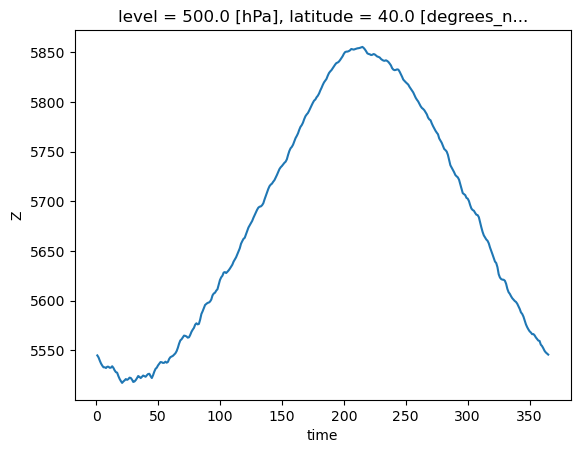

In [80]:
annualcycda.sel(latitude = 40, level = 500).plot()

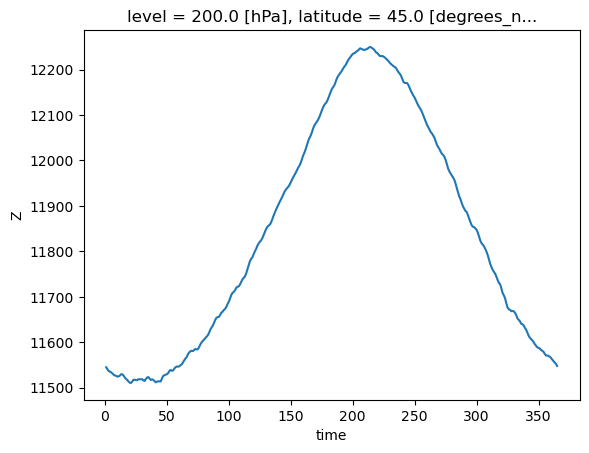

In [81]:
annualcycda.sel(latitude = 45, level = 200).plot()

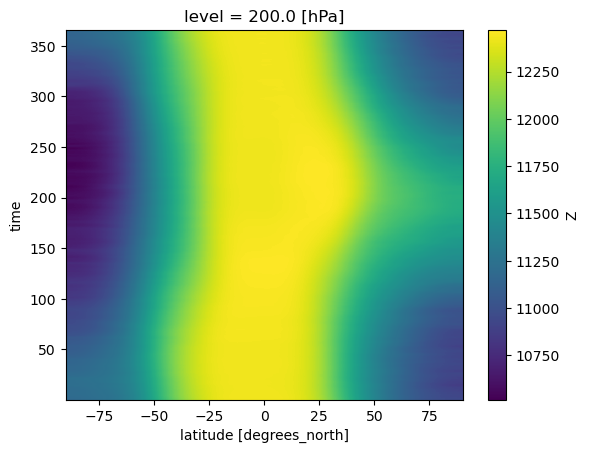

In [82]:
annualcycda.sel(level = 200).plot()

In [83]:
anncycfile = annualcycda.to_netcdf('zmzdaily_annual_cycle.nc')

In [20]:
anncyc = xr.open_mfdataset('zmzdaily_annual_cycle.nc').Z

In [21]:
anncyc

<xarray.DataArray 'Z' (level: 37, time: 365, latitude: 721)> Size: 78MB
dask.array<open_dataset-Z, shape=(37, 365, 721), dtype=float64, chunksize=(37, 365, 721), chunktype=numpy.ndarray>
Coordinates:
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * time      (time) int64 3kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0

In [16]:
z2005 = xr.open_mfdataset(filepath + 'zmzdaily2005.nc').Z

In [17]:
z2005

<xarray.DataArray 'Z' (level: 37, time: 365, latitude: 721)> Size: 39MB
dask.array<open_dataset-Z, shape=(37, 365, 721), dtype=float32, chunksize=(37, 365, 721), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * time      (time) datetime64[ns] 3kB 2005-01-01 2005-01-02 ... 2005-12-31

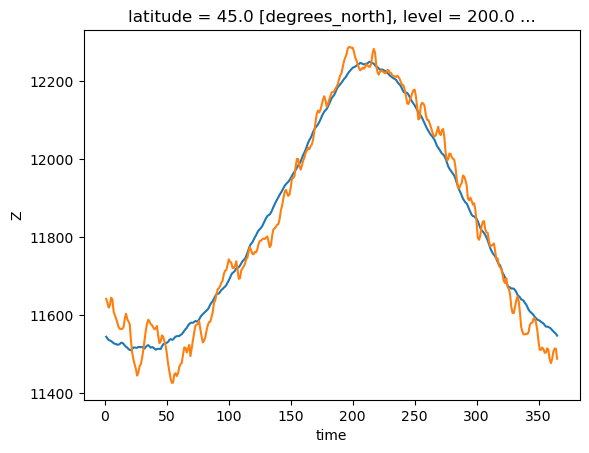

In [26]:
anncyc.sel(latitude = 45, level = 200).plot()
cheese = np.arange(1,366)
z2005new = z2005.assign_coords({'time': cheese})
z2005new.sel(latitude = 45, level = 200).plot()